# Purchase Propensity — Business Impact & Decision

### From Prediction to Product Action

This notebook translates the purchase propensity model into a practical product decision.

The previous notebook established that early-session information can be used to rank sessions by purchase propensity. The goal here is not to build another model, but to determine **how that signal could be used responsibly in a product intervention and experimentation strategy.**

### Business Question

> **If we can identify sessions with higher purchase propensity, how should the product team use that information, and what should be tested next?**

## 1. Project Context

The overall project began with three stakeholder questions:

1. **Where do we lose users before purchase?**
2. **Which channels bring buyers, not just visits?**
3. **Which product improvement should we test first?**

The analysis produced three complementary layers:

| Layer | Question | Main Finding |
|---|---|---|
| Product Analytics | Where is the funnel leaking? | Product View → Add to Cart is the largest observed funnel leak |
| Lifecycle Analysis | Which users behave differently? | Returning sessions convert ~4.6× better than new sessions |
| Predictive Analytics | Who is more likely to purchase? | The model can concentrate likely purchasers into a high-propensity segment |

The predictive model is therefore **not the final answer**.

Its purpose is to add a targeting layer to the product decision.

## 2. Validated Model Results

The final XGBoost model was evaluated on a **future time-based test set** rather than a random split.

### Model performance

| Metric | Result |
|---|---:|
| ROC-AUC | **0.716** |
| PR-AUC | **0.031** |
| Test sessions | **81,527** |
| Test purchase rate | **1.12%** |

The model demonstrates useful ranking ability, but it should not be interpreted as a perfect purchase predictor.

Because purchase is a rare event, the **1.12% purchase prevalence provides the appropriate context for interpreting PR-AUC**. The PR-AUC of 0.031 is above the rare-event baseline, indicating that the model provides useful ranking signal.

The business value becomes clearer through lift analysis.

## 3. Top-Decile Business Impact

The model was used to rank test sessions from highest to lowest predicted purchase propensity.

The highest-scored 10% of sessions showed:

| Metric | Result |
|---|---:|
| Overall purchase rate | **1.12%** |
| Top 10% purchase rate | **4.02%** |
| Top 10% lift | **3.60×** |
| Purchases captured by top 10% | **35.96%** |

### Interpretation

The top 10% of sessions had a purchase rate approximately **3.6 times higher** than the overall test population.

More importantly, this segment contained approximately **36% of all observed purchasers**, despite representing only 10% of test sessions.

This means the model is useful as a **prioritization mechanism**.

It does not tell the business exactly which users will purchase. Instead, it helps concentrate attention on a smaller segment with substantially higher observed purchase propensity.

### Propensity Ranking Creates a Concentrated Buyer Segment

The highest-propensity 10% of sessions had a substantially higher observed purchase rate than the overall test population. This illustrates why the model is more useful as a ranking and prioritization tool than as a binary purchase predictor.

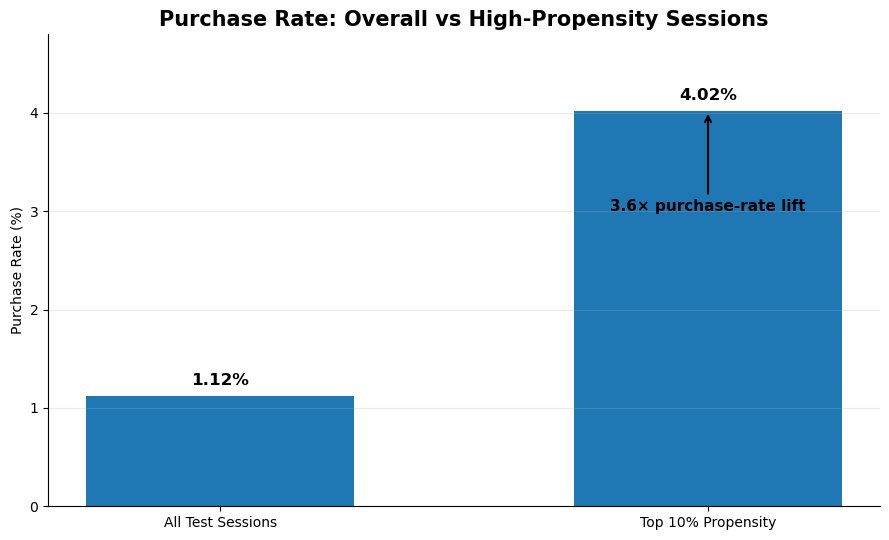

In [6]:
import matplotlib.pyplot as plt

segments = [
    "All Test Sessions",
    "Top 10% Propensity"
]

purchase_rates = [
    1.12,
    4.02
]

plt.figure(figsize=(9, 5.5))

bars = plt.bar(
    segments,
    purchase_rates,
    width=0.55
)

plt.ylabel("Purchase Rate (%)")
plt.title(
    "Purchase Rate: Overall vs High-Propensity Sessions",
    fontsize=15,
    fontweight="bold"
)

# Add value labels
for bar, value in zip(bars, purchase_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Add lift annotation
lift = purchase_rates[1] / purchase_rates[0]

plt.annotate(
    f"{lift:.1f}× purchase-rate lift",
    xy=(1, purchase_rates[1]),
    xytext=(1, 3.0),
    ha="center",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    )
)

plt.ylim(0, 4.8)

# Clean up chart
plt.grid(
    axis="y",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Why the Lift Matters

A model with a moderate AUC is not automatically useful to a business.

The important question is:

> **Can the model help us make a better decision than treating every session the same way?**

In this case, the answer is promising.

If the product team has limited capacity for a personalized intervention, it does not necessarily need to intervene across the entire audience.

The model provides a way to prioritize a smaller group where purchase propensity is more concentrated.

However, the model should **not** be used to automatically discount users or assume that high-propensity users would purchase because of the intervention.

The model identifies **who to prioritize**.

An experiment is still required to determine **whether the intervention actually causes additional purchases or retention**.

## 5. Targeting Decision

### Recommended initial targeting segment: Top 10%

The **top 10% propensity segment** is a reasonable starting point for experimentation because it provides a strong balance between concentration and audience size.

The observed results show:

- **3.60× purchase-rate lift**
- **4.02% purchase rate**
- **35.96% of observed purchasers captured**

This makes the top 10% a useful candidate segment for a controlled intervention.

### Important caveat

This is a **starting hypothesis, not a final targeting threshold**.

The optimal threshold should ultimately depend on:

- intervention cost,
- expected incremental revenue,
- user experience impact,
- available product capacity,
- and experimental results.

The model's ranking should therefore be treated as a decision-support signal rather than a hard business rule.

## 6. Recommended Product Intervention

The model should not be used primarily to offer discounts to users who already appear likely to purchase.

Instead, the intervention should address the product-discovery problem identified in the funnel analysis.

### Proposed intervention

For eligible high-propensity sessions, test an improved first-session product discovery experience, such as:

- more relevant product recommendations,
- clearer product-category navigation,
- stronger product discovery calls-to-action,
- or improved visibility of relevant products.

The exact treatment should be selected based on product feasibility.

### Why this intervention?

The funnel analysis identified **Product View → Add to Cart** as the largest observed funnel leak.

The lifecycle analysis also showed that returning users convert substantially better than new users.

Therefore, improving the first-session discovery experience is a logical way to help new users progress further through the funnel and potentially improve future engagement.

## 7. Prediction + Experiment: Two Different Questions

The predictive model and the experiment answer different questions.

### Predictive model

> **Who is more likely to purchase?**

The XGBoost model provides a ranking signal and identifies a high-propensity segment.

### Experiment

> **Does the proposed intervention actually improve user behavior?**

The experiment determines whether the intervention causes an improvement.

### Combined strategy

**Model → Target eligible sessions → Randomize treatment/control → Measure incremental impact**

The model should therefore be used for **targeting or prioritization**, while the A/B test provides the evidence for whether the product change works.

This distinction is important because **prediction does not establish causality**.

## 8. Recommended Experiment

The experiment designed in Notebook 1 used **7-day retention as the primary metric**, with conversion and funnel metrics as secondary measures.

### Proposed structure

**Population:** New users / first-session users

**Control:** Existing first-session product discovery experience

**Treatment:** Improved product discovery / recommendations / CTA experience

**Primary metric:** 7-day retention

**Secondary metrics:**
- Product View → Add to Cart
- Purchase conversion
- Engagement

**Guardrails:**
- Revenue per session
- Purchase rate
- User experience / engagement quality

### Decision logic

The experiment should only be considered successful if the treatment improves the primary metric without creating unacceptable deterioration in guardrail metrics.

The previously calculated planning assumptions used a baseline 7-day retention of approximately 5.5%, a 20% relative MDE, α = 0.05, and 80% power.

## 9. What We Cannot Claim

The 3.60× lift is an **observational ranking result**.

It does **not** mean:

> “The model caused a 3.6× increase in purchases.”

It means:

> **“Sessions ranked in the top 10% by the model had a purchase rate 3.60× the overall test-set rate.”**

Similarly, the model capturing 35.96% of purchasers does not mean that targeting those sessions would generate 35.96% additional purchases.

To estimate incremental impact, the intervention must be tested experimentally against a randomized control group.

## 10. Limitations

### 1. Observational data

The model identifies predictive relationships but does not establish causality.

### 2. Rare purchase outcome

Purchase occurs in only a small fraction of sessions, making accuracy an unsuitable primary evaluation metric.

### 3. GA4 sample limitations

The Google Merchandise Store dataset is an obfuscated public sample. Results should therefore be interpreted as directional rather than as production business estimates.

### 4. Acquisition attribution

The available acquisition fields represent user-acquisition information and should not be interpreted as perfect session-level marketing attribution.

### 5. Limited observation window

The dataset covers approximately three months, so longer-term behavior may not be fully represented.

### 6. Prediction scope

The model uses information available at the start of the session. It intentionally excludes behavioral signals that occur later in the session to avoid leakage.

### 7. Threshold selection

The top 10% is a practical starting point based on observed lift, not a universally optimal threshold. The final threshold should depend on intervention cost, capacity, and experimental results.

## 11. Final Business Recommendation

The analysis suggests that the primary opportunity is **not simply acquiring more traffic**, but improving the journey from product discovery toward purchase and strengthening early user engagement.

The largest observed funnel leak was **Product View → Add to Cart**, while returning sessions converted approximately **4.6× better than new sessions**.

The purchase propensity model adds a targeting layer: the top 10% of predicted sessions showed a **4.02% purchase rate versus 1.12% overall**, producing **3.60× lift** and capturing approximately **35.96% of observed purchasers**.

### Recommended next action

1. **Improve first-session product discovery** through better recommendations, navigation, or calls-to-action.
2. **Use the propensity model as a prioritization signal**, initially considering the top 10% segment.
3. **Run a randomized experiment** rather than assuming the intervention will create incremental purchases.
4. Use **7-day retention as the primary experiment metric**, with funnel conversion and purchase behavior as secondary metrics.
5. Monitor revenue and engagement as guardrails.
6. Reassess the targeting threshold after experimental results and intervention economics are available.

### Final decision

> **Use analytics to identify the problem, use the propensity model to prioritize the audience, and use experimentation to prove whether the product change actually works.**

This keeps the recommendation data-driven while avoiding unsupported causal claims.

## 12. Interview Story

> “I analyzed the Google Merchandise Store GA4 dataset to understand where users were dropping before purchase, which acquisition and lifecycle segments were more valuable, and what product change should be tested.
>
> I found that the largest observed funnel leak was from product view to add-to-cart, and returning sessions converted roughly 4.6 times better than new sessions.
>
> I then built a purchase propensity model using only information available at the beginning of a session to avoid leakage. I used a time-based split so the model was evaluated on future data. XGBoost achieved a 0.716 ROC-AUC and 0.031 PR-AUC.
>
> More importantly, the model had business lift: the top 10% of scored sessions had a 4.02% purchase rate compared with 1.12% overall, giving 3.6× lift and capturing about 36% of observed purchasers.
>
> I would not interpret that as causal. Instead, I would use the model to prioritize a segment for an intervention, then run an A/B test to determine whether improving first-session product discovery actually increases retention and conversion.
>
> So the final recommendation is: identify the funnel problem, prioritize the audience using predictive scoring, and validate the product intervention experimentally.”